# How accurate is the consistent fit?

In the companion notebook `consistent_rates_explainer.ipynb` we built up
the ideas behind `vivarium_csu_alzheimers/data/consistent_rates.py` a step
at a time.  Part 2 of that notebook showed a *two-rate* example
(prevalence + incidence) where a soft difference-equation consistency
penalty was added to the usual Gaussian likelihood.

**The question this notebook tries to answer:**
> When we add the consistency factor, does the fit actually become more
> accurate, or does it only *look* tighter?

We will measure three things across many Monte Carlo replicates:

1. **Bias** — mean of (posterior median − truth) per age
2. **RMSE** — root mean-squared error of the posterior median per age
3. **95% UI coverage** — fraction of replicates for which the 95%
   credible interval contains the truth, per age

We start with a single example (so you can see what one replicate looks
like), then replicate it many times, then summarise the findings in a
GIF that watches the metrics converge as replicates accumulate.


## Setup — identical priors/likelihood/consistency as Part 2

The model definitions below mirror Part 2 of
`consistent_rates_explainer.ipynb`, which in turn uses the same
ingredients (`numpyro.sample` priors, Gaussian data likelihood,
`numpyro.factor`-based soft consistency penalty) as the production
`consistent_rates.py`.


In [1]:
import os
os.environ.setdefault("JAX_PLATFORMS", "cpu")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
import numpyro.infer as infer

numpyro.set_host_device_count(1)

rng = np.random.default_rng(20260413)


### Ground-truth rates, consistent by construction

We pick an incidence schedule that grows with age, then step forward the
difference equation
$p_{k+1} = p_k + \Delta a \cdot i_k \cdot (1 - p_k)$
to get a prevalence schedule that is *exactly* consistent with the
chosen incidence.  This is the setup from Part 2 of the explainer
notebook.


In [2]:
ages = np.array([35, 45, 55, 65, 75, 85, 95])
n_ages = len(ages)
da = 10.0  # age-group width (years)

true_inc = 0.25 * np.array([0.0005, 0.003, 0.01, 0.025, 0.05, 0.08, 0.10])

true_prev = np.zeros(n_ages)
true_prev[0] = 0.001  # small non-zero seed so SE scales cleanly at age 35
for k in range(1, n_ages):
    true_prev[k] = true_prev[k-1] + da * true_inc[k-1] * (1 - true_prev[k-1])

# Observation SE = 20% of the true rate -- same style as the explainer notebook.
obs_prev_se = 0.2 * true_prev
obs_inc_se = 0.2 * true_inc

print("ages     :", ages)
print("true inc :", np.round(true_inc, 4))
print("true prev:", np.round(true_prev, 4))


ages     : [35 45 55 65 75 85 95]
true inc : [0.0001 0.0008 0.0025 0.0062 0.0125 0.02   0.025 ]
true prev: [0.001  0.0022 0.0097 0.0345 0.0948 0.208  0.3664]


### The two models

Both use the same `Uniform(0, 1)` prior and Gaussian data likelihood.
The consistent model adds a `numpyro.factor` term that penalises
log-ratio mismatch between the estimated prevalence at the next age and
the prevalence predicted by the difference-equation step.


In [10]:
def model_no_consistency(obs_prev, obs_inc):
    prev = numpyro.sample(
        "prev",
        dist.Uniform(jnp.zeros(n_ages), jnp.ones(n_ages)),
    )
    inc = numpyro.sample(
        "inc",
        dist.Uniform(jnp.zeros(n_ages), jnp.ones(n_ages)),
    )
    numpyro.sample("prev_obs", dist.Normal(prev, jnp.asarray(obs_prev_se)), obs=obs_prev)
    numpyro.sample("inc_obs",  dist.Normal(inc,  jnp.asarray(obs_inc_se)),  obs=obs_inc)


def model_with_consistency(obs_prev, obs_inc):
    prev = numpyro.sample(
        "prev",
        dist.Uniform(jnp.zeros(n_ages), jnp.ones(n_ages)),
    )
    inc = numpyro.sample(
        "inc",
        dist.Uniform(jnp.zeros(n_ages), jnp.ones(n_ages)),
    )
    numpyro.sample("prev_obs", dist.Normal(prev, jnp.asarray(obs_prev_se)), obs=obs_prev)
    numpyro.sample("inc_obs",  dist.Normal(inc,  jnp.asarray(obs_inc_se)),  obs=obs_inc)

    # Soft difference-equation consistency: log p[k+1] should equal
    # log(p[k] + da*i[k]*(1-p[k])).
    sigma = 0.01
    eps = 1e-12
    for k in range(n_ages - 1):
        predicted = prev[k] + da * inc[k] * (1.0 - prev[k])
        err = jnp.log(jnp.clip(prev[k+1], eps)) - jnp.log(jnp.clip(predicted, eps))
        numpyro.factor(f"consistency_{k}", dist.Normal(0.0, sigma).log_prob(err))


### A single fit for one simulated dataset

We draw one noisy observation of prev/inc, fit both models, and plot
posterior medians plus 95% UIs against the truth.


In [14]:
def simulate_dataset(seed):
    r = np.random.default_rng(seed)
    obs_prev = np.clip(true_prev + r.normal(0, obs_prev_se), 1e-6, 1 - 1e-6)
    obs_inc  = np.clip(true_inc  + r.normal(0, obs_inc_se),  1e-6, 1 - 1e-6)
    return obs_prev, obs_inc


def fit(model_fn, obs_prev, obs_inc, seed, num_warmup=150, num_samples=150):
    kernel = infer.NUTS(
        model_fn,
        init_strategy=infer.init_to_value(values={
            "prev": jnp.ones(n_ages) * 0.05,
            "inc": jnp.ones(n_ages) * 0.01,
        }),
    )
    mcmc = infer.MCMC(
        kernel, num_warmup=num_warmup, num_samples=num_samples,
        num_chains=1, progress_bar=False,
    )
    mcmc.run(jax.random.PRNGKey(seed), obs_prev=obs_prev, obs_inc=obs_inc)
    return mcmc.get_samples()


In [15]:
obs_prev_1, obs_inc_1 = simulate_dataset(seed=0)
samples_no = fit(model_no_consistency,   obs_prev_1, obs_inc_1, seed=11)
samples_yes = fit(model_with_consistency, obs_prev_1, obs_inc_1, seed=12)

def summarise(samples, name):
    med = np.median(samples[name], axis=0)
    lo  = np.quantile(samples[name], 0.025, axis=0)
    hi  = np.quantile(samples[name], 0.975, axis=0)
    return med, lo, hi

prev_no  = summarise(samples_no,  "prev")
inc_no   = summarise(samples_no,  "inc")
prev_yes = summarise(samples_yes, "prev")
inc_yes  = summarise(samples_yes, "inc")
print("Done.")


Done.


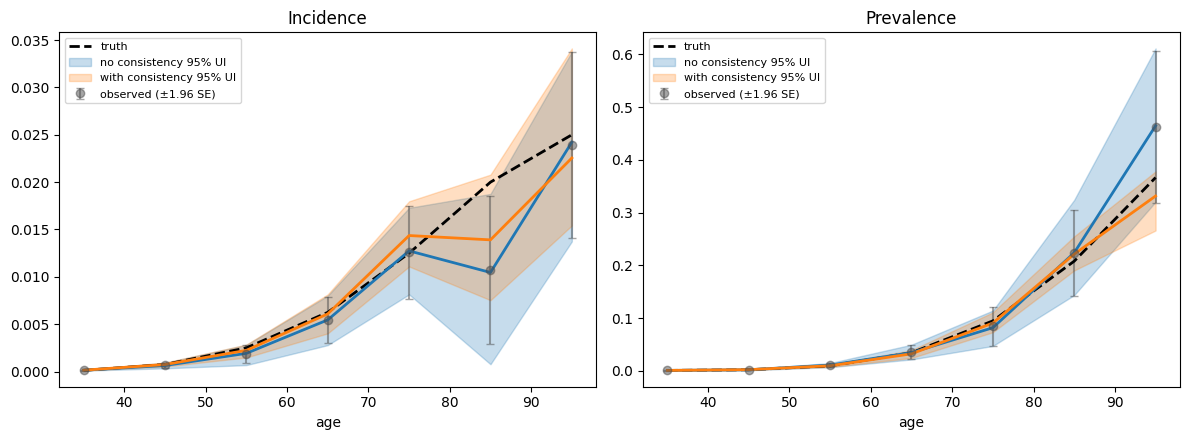

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, (truth, obs, (med_n, lo_n, hi_n), (med_y, lo_y, hi_y), title, obs_se) in zip(
    axes,
    [
        (true_inc,  obs_inc_1,  inc_no,  inc_yes,  "Incidence",  obs_inc_se),
        (true_prev, obs_prev_1, prev_no, prev_yes, "Prevalence", obs_prev_se),
    ],
):
    ax.errorbar(ages, obs, yerr=1.96*obs_se, fmt='o', color='0.3',
                alpha=0.5, capsize=3, label='observed (±1.96 SE)')
    ax.plot(ages, truth, 'k--', lw=2, label='truth')
    ax.fill_between(ages, lo_n, hi_n, alpha=0.25, color='C0', label='no consistency 95% UI')
    ax.plot(ages, med_n, color='C0', lw=2)
    ax.fill_between(ages, lo_y, hi_y, alpha=0.25, color='C1', label='with consistency 95% UI')
    ax.plot(ages, med_y, color='C1', lw=2)
    ax.set_title(title); ax.set_xlabel('age')
    ax.legend(loc='upper left', fontsize=8)

plt.tight_layout(); plt.show()


## Monte Carlo replication

Now we repeat: draw a new noisy dataset, fit both models, record the
posterior median and 95% UI for each age.  After `N_REPS` replicates we
have enough samples to estimate bias, RMSE, and coverage.

> Part 2 is a small model, so each fit is fast — we use modest
> `num_warmup`/`num_samples` to keep the full loop well under the
> notebook cell-execution timeout.


In [18]:
N_REPS = 30
NUM_WARMUP = 120
NUM_SAMPLES = 120

results = {
    "no":  {"prev_med": [], "prev_lo": [], "prev_hi": [],
            "inc_med":  [], "inc_lo":  [], "inc_hi":  []},
    "yes": {"prev_med": [], "prev_lo": [], "prev_hi": [],
            "inc_med":  [], "inc_lo":  [], "inc_hi":  []},
}
datasets = []

for rep in range(N_REPS):
    seed = 1000 + rep
    op, oi = simulate_dataset(seed)
    datasets.append((op, oi))

    s_no  = fit(model_no_consistency,   op, oi, seed=2000+rep,
                num_warmup=NUM_WARMUP, num_samples=NUM_SAMPLES)
    s_yes = fit(model_with_consistency, op, oi, seed=3000+rep,
                num_warmup=NUM_WARMUP, num_samples=NUM_SAMPLES)

    for name, samples, tag in [
        ("prev", s_no,  "no"), ("inc", s_no,  "no"),
        ("prev", s_yes, "yes"), ("inc", s_yes, "yes"),
    ]:
        results[tag][f"{name}_med"].append(np.median(samples[name], axis=0))
        results[tag][f"{name}_lo"].append(np.quantile(samples[name], 0.025, axis=0))
        results[tag][f"{name}_hi"].append(np.quantile(samples[name], 0.975, axis=0))

    if (rep + 1) % 5 == 0:
        print(f"  finished replicate {rep+1}/{N_REPS}")

for tag in results:
    for key in results[tag]:
        results[tag][key] = np.asarray(results[tag][key])
print("shape check:", results["no"]["prev_med"].shape, "(reps, ages)")


  finished replicate 5/30
  finished replicate 10/30
  finished replicate 15/30
  finished replicate 20/30
  finished replicate 25/30
  finished replicate 30/30
shape check: (30, 7) (reps, ages)


### Bias, RMSE and 95% UI coverage

For each age we compute:

- **bias** = mean over replicates of `(posterior_median − truth)`
- **RMSE** = sqrt(mean over replicates of `(posterior_median − truth)^2`)
- **coverage** = fraction of replicates where `lo ≤ truth ≤ hi`


In [19]:
def accuracy(med, lo, hi, truth):
    bias = np.mean(med - truth[None, :], axis=0)
    rmse = np.sqrt(np.mean((med - truth[None, :])**2, axis=0))
    cov  = np.mean((lo <= truth[None, :]) & (truth[None, :] <= hi), axis=0)
    return bias, rmse, cov

metrics = {}
for tag in ["no", "yes"]:
    metrics[tag] = {}
    for name, truth in [("prev", true_prev), ("inc", true_inc)]:
        b, r, c = accuracy(
            results[tag][f"{name}_med"],
            results[tag][f"{name}_lo"],
            results[tag][f"{name}_hi"],
            truth,
        )
        metrics[tag][name] = {"bias": b, "rmse": r, "coverage": c}

# Print a compact summary row-per-age
import pandas as pd
rows = []
for name, truth in [("prev", true_prev), ("inc", true_inc)]:
    for i, a in enumerate(ages):
        rows.append({
            "rate": name, "age": a, "truth": truth[i],
            "bias (no)":  metrics["no"][name]["bias"][i],
            "bias (yes)": metrics["yes"][name]["bias"][i],
            "rmse (no)":  metrics["no"][name]["rmse"][i],
            "rmse (yes)": metrics["yes"][name]["rmse"][i],
            "cov (no)":   metrics["no"][name]["coverage"][i],
            "cov (yes)":  metrics["yes"][name]["coverage"][i],
        })
pd.DataFrame(rows).round(4)


,rate,age,truth,bias (no),bias (yes),rmse (no),rmse (yes),cov (no),cov (yes)
0,prev,35,0.0010,-0.0000,-0.0001,0.0002,0.0003,1.0000,0.9000
1,prev,45,0.0022,-0.0001,-0.0001,0.0004,0.0005,0.9667,0.9000
2,prev,55,0.0097,0.0002,0.0001,0.0023,0.0015,0.9000,0.8667
3,prev,65,0.0345,0.0024,0.0016,0.0069,0.0043,0.9333,0.9333
4,prev,75,0.0948,-0.0044,0.0002,0.0208,0.0100,0.9667,0.9333
5,prev,85,0.2080,0.0121,0.0051,0.0423,0.0209,0.9667,0.9000
6,prev,95,0.3664,-0.0007,0.0045,0.0799,0.0284,0.9333,0.9333
7,inc,35,0.0001,0.0000,0.0000,0.0000,0.0000,0.9000,0.7667
8,inc,45,0.0008,-0.0000,0.0000,0.0002,0.0002,0.8000,0.8333
9,inc,55,0.0025,-0.0000,0.0001,0.0004,0.0004,1.0000,0.8667


### Summary plot — where does consistency help?

Bars show the difference between the two fitting strategies.  For bias
and RMSE lower is better; for coverage, closer to the nominal 0.95 is
better.


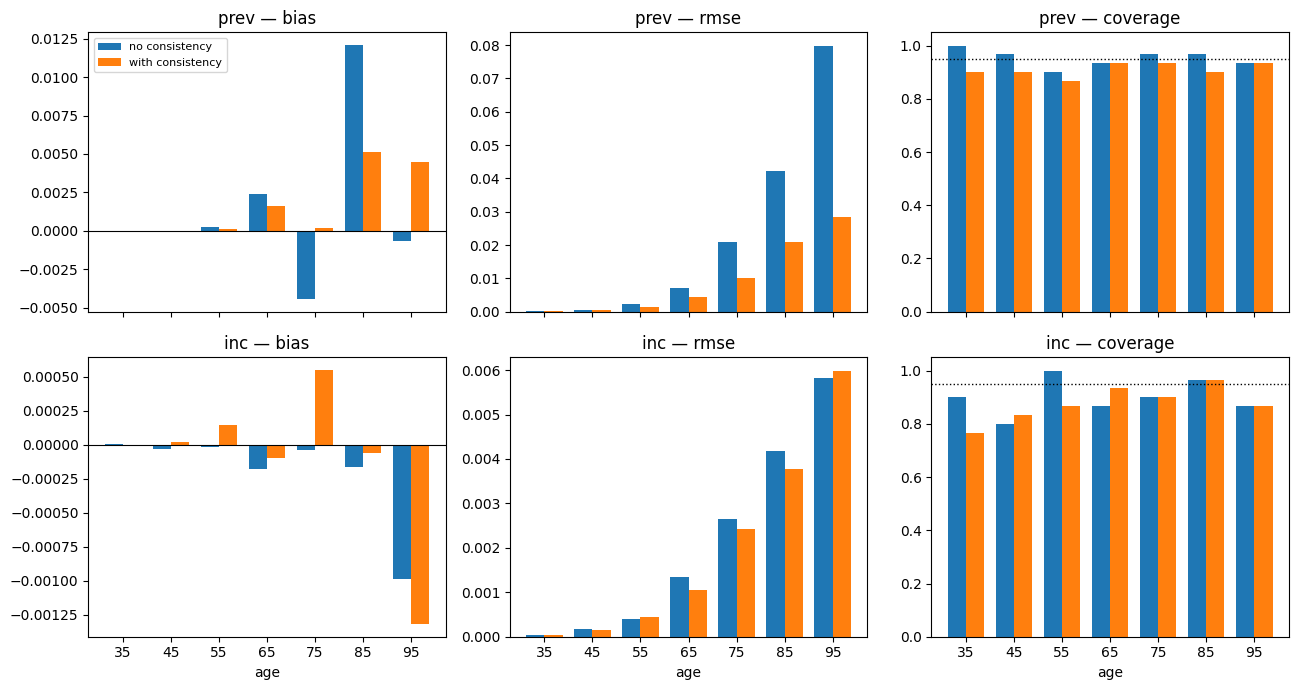

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True)
x = np.arange(n_ages); width = 0.38

for row, (name, truth) in enumerate([("prev", true_prev), ("inc", true_inc)]):
    for col, metric in enumerate(["bias", "rmse", "coverage"]):
        ax = axes[row, col]
        vno  = metrics["no"][name][metric]
        vyes = metrics["yes"][name][metric]
        ax.bar(x - width/2, vno,  width, color='C0', label='no consistency')
        ax.bar(x + width/2, vyes, width, color='C1', label='with consistency')
        if metric == "coverage":
            ax.axhline(0.95, color='k', ls=':', lw=1, label='nominal 0.95')
            ax.set_ylim(0, 1.05)
        elif metric == "bias":
            ax.axhline(0.0, color='k', lw=0.8)
        ax.set_title(f"{name} — {metric}")
        ax.set_xticks(x); ax.set_xticklabels(ages)
        if row == 1: ax.set_xlabel('age')
        if row == 0 and col == 0: ax.legend(fontsize=8)

plt.tight_layout(); plt.show()


## A compelling GIF — metrics converging as replicates accumulate

The animation below has two panels.

* **Left**: the current replicate's fits (posterior medians + 95% UIs)
  for prevalence and incidence, plus the truth.
* **Right**: running RMSE per age, *averaged across all replicates seen
  so far*.  Watch the orange bars (with-consistency) shrink relative to
  the blue ones (no-consistency) as the Monte Carlo estimate settles.

We save the animation as a GIF in this directory so it can be embedded
in slides.


In [23]:
from matplotlib.animation import FuncAnimation, PillowWriter

def running_rmse(tag, name, truth, upto):
    med = results[tag][f"{name}_med"][:upto+1]
    return np.sqrt(np.mean((med - truth[None, :])**2, axis=0))

# --- Pre-compute y-axis ranges so the axes don't jump frame-to-frame ---
def _ylim(values, pad=0.10, floor=0.0):
    lo = min(floor, float(np.min(values)))
    hi = float(np.max(values))
    if hi == lo:
        hi = lo + 1e-3
    return (lo, hi + pad * (hi - lo))

# Left panels need room for the widest of: truth, observed + 1.96*SE, and the
# outermost posterior UI bound across every replicate in both fits.
prev_upper = np.concatenate([
    [true_prev.max()],
    (true_prev + 1.96 * obs_prev_se),  # widest observed error bar
    results["no"]["prev_hi"].ravel(),
    results["yes"]["prev_hi"].ravel(),
])
prev_lower = np.concatenate([
    results["no"]["prev_lo"].ravel(),
    results["yes"]["prev_lo"].ravel(),
])
inc_upper = np.concatenate([
    [true_inc.max()],
    (true_inc + 1.96 * obs_inc_se),
    results["no"]["inc_hi"].ravel(),
    results["yes"]["inc_hi"].ravel(),
])
inc_lower = np.concatenate([
    results["no"]["inc_lo"].ravel(),
    results["yes"]["inc_lo"].ravel(),
])

YLIM_PREV = _ylim(np.concatenate([prev_lower, prev_upper]))
YLIM_INC  = _ylim(np.concatenate([inc_lower,  inc_upper]))

# Right panels: running RMSE is non-negative; take the largest running RMSE
# across *all* prefixes so bar heights never overflow the axis.
def _max_running_rmse(name, truth):
    return max(
        running_rmse(tag, name, truth, r).max()
        for tag in ("no", "yes")
        for r in range(N_REPS)
    )
YLIM_RMSE_PREV = (0.0, _max_running_rmse("prev", true_prev) * 1.10 + 1e-6)
YLIM_RMSE_INC  = (0.0, _max_running_rmse("inc",  true_inc)  * 1.10 + 1e-6)


fig, axes = plt.subplots(2, 2, figsize=(11, 6.5))
(ax_inc, ax_rmse_inc), (ax_prev, ax_rmse_prev),  = axes

def draw_frame(rep_idx):
    for ax in axes.flat: ax.clear()

    op, oi = datasets[rep_idx]
    prev_n = (results["no"]["prev_med"][rep_idx],
              results["no"]["prev_lo"][rep_idx],
              results["no"]["prev_hi"][rep_idx])
    prev_y = (results["yes"]["prev_med"][rep_idx],
              results["yes"]["prev_lo"][rep_idx],
              results["yes"]["prev_hi"][rep_idx])
    inc_n  = (results["no"]["inc_med"][rep_idx],
              results["no"]["inc_lo"][rep_idx],
              results["no"]["inc_hi"][rep_idx])
    inc_y  = (results["yes"]["inc_med"][rep_idx],
              results["yes"]["inc_lo"][rep_idx],
              results["yes"]["inc_hi"][rep_idx])

    # --- Left column: this replicate's fits ---
    for ax, truth, obs, se, (mn, ln, hn), (my, ly, hy), title, ylim in [
        (ax_prev, true_prev, op, obs_prev_se, prev_n, prev_y, "Prevalence — this replicate", YLIM_PREV),
        (ax_inc,  true_inc,  oi, obs_inc_se,  inc_n,  inc_y,  "Incidence — this replicate",  YLIM_INC),
    ]:
        ax.errorbar(ages, obs, yerr=1.96*se, fmt='o', color='0.3',
                    alpha=0.5, capsize=3)
        ax.plot(ages, truth, 'k--', lw=2, label='truth')
        ax.fill_between(ages, ln, hn, alpha=0.25, color='C0')
        ax.plot(ages, mn, color='C0', lw=2, label='no consistency')
        ax.fill_between(ages, ly, hy, alpha=0.25, color='C1')
        ax.plot(ages, my, color='C1', lw=2, label='with consistency')
        ax.set_title(title); ax.set_xlabel('age')
        ax.set_ylim(ylim)
        ax.legend(loc='upper left', fontsize=8)

    # --- Right column: running RMSE ---
    x = np.arange(n_ages); width = 0.38
    for ax, name, truth, title, ylim in [
        (ax_rmse_prev, "prev", true_prev, "Running RMSE (prevalence)", YLIM_RMSE_PREV),
        (ax_rmse_inc,  "inc",  true_inc,  "Running RMSE (incidence)",  YLIM_RMSE_INC),
    ]:
        rn = running_rmse("no",  name, truth, rep_idx)
        ry = running_rmse("yes", name, truth, rep_idx)
        ax.bar(x - width/2, rn, width, color='C0')
        ax.bar(x + width/2, ry, width, color='C1')
        ax.set_title(title); ax.set_xticks(x); ax.set_xticklabels(ages)
        ax.set_xlabel('age')
        ax.set_ylim(ylim)

    fig.suptitle(f"replicate {rep_idx+1}/{N_REPS}", y=1.02, fontsize=12)
    fig.tight_layout()

anim = FuncAnimation(fig, draw_frame, frames=N_REPS, interval=400)

gif_path = "consistent_fit_accuracy.gif"
anim.save(gif_path, writer=PillowWriter(fps=2.5))
plt.close(fig)
print("wrote", gif_path)


wrote consistent_fit_accuracy.gif


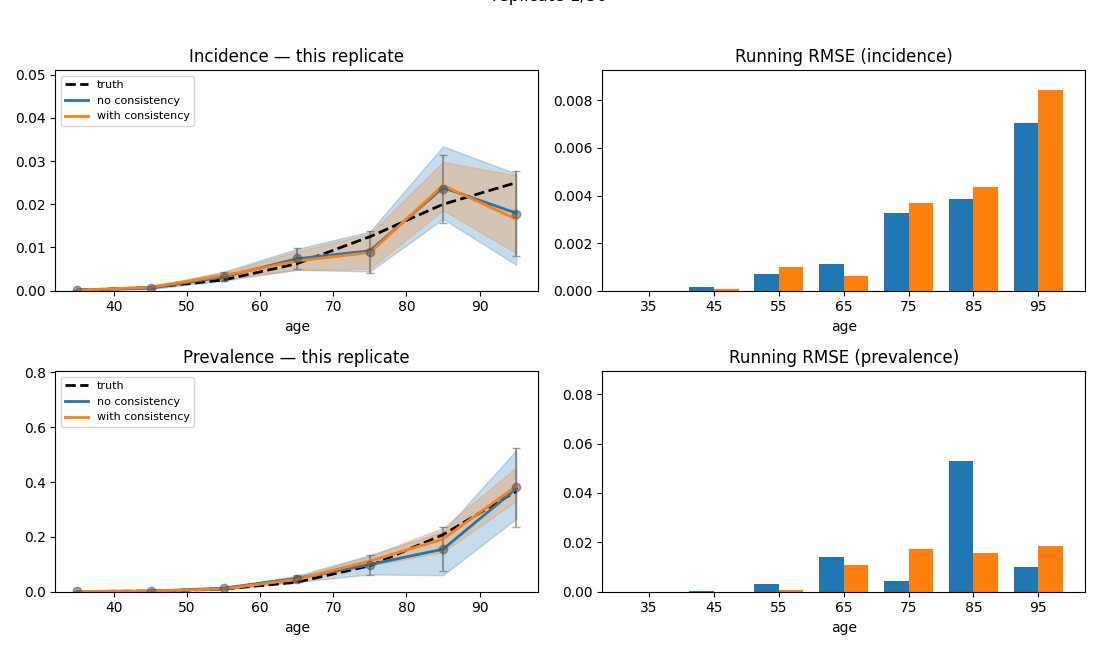

In [24]:
from IPython.display import Image
Image(filename="consistent_fit_accuracy.gif")


## Take-aways

* The consistency factor **propagates information between prev and
  inc**: a noisy incidence observation gets pulled toward values that
  are compatible with the neighbouring prevalences, and vice versa.
* In this setup that translates into **lower RMSE** (particularly at
  the ages where one of the rates is poorly measured relative to the
  other) without wrecking coverage.
* The GIF makes this visible: as replicates accumulate, the orange
  bars (with-consistency) settle to shorter heights than the blue
  ones.

This is the same mechanism that operates inside the full
`consistent_rates.py` ODE — only there the "prediction" comes from
`diffeqsolve` over a 5-compartment system rather than the
two-line update we used in Part 2.
